In [2]:
import os
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


IMPORTS AND CONFIGURATION

In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import models
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import json
import time
import os

# Configuration
TEXT_DIR = "/content/drive/MyDrive/threec/processed"
IMAGE_DIR = "/content/drive/MyDrive/threec/processed_images"
SAVE_DIR = "/content/drive/MyDrive/threec/checkpoints"

BATCH_SIZE = 4
PAYLOAD_SIZE = 4096
IMAGE_SIZE = 256
NUM_EPOCHS = 20
NUM_WORKERS = 2

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print("="*70)
print("STEGANOGRAPHY TRAINING - ALL ALIGNED")
print("="*70)
print(f"\nDevice: {device}")
if device == 'cuda':
    print(f"   GPU: {torch.cuda.get_device_name(0)}")
print(f"Batch size: {BATCH_SIZE}")
print(f"Payload size: {PAYLOAD_SIZE}")
print(f"Epochs: {NUM_EPOCHS}")

os.makedirs(SAVE_DIR, exist_ok=True)

STEGANOGRAPHY TRAINING - ALL ALIGNED

Device: cuda
Batch size: 4
Payload size: 4096
Epochs: 20


DATASET CLASS

In [4]:
class SteganographyDataset(Dataset):
    """Combines cover images with encrypted text payloads"""

    def __init__(self, images, labels, payloads, mode='train'):
        self.images = images
        self.labels = labels
        self.payloads = payloads
        self.mode = mode

        print(f"✓ {mode.upper()} Dataset: {images.shape}")

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        # Get cover image [H, W, C] → [C, H, W]
        cover = torch.tensor(self.images[idx], dtype=torch.float32).permute(2, 0, 1)

        # Get random payload
        payload_idx = np.random.randint(0, len(self.payloads))
        payload = torch.tensor(self.payloads[payload_idx], dtype=torch.float32)

        # Ensure correct payload size
        if payload.shape[0] != PAYLOAD_SIZE:
            if payload.shape[0] < PAYLOAD_SIZE:
                padding = torch.zeros(PAYLOAD_SIZE - payload.shape[0])
                payload = torch.cat([payload, padding])
            else:
                payload = payload[:PAYLOAD_SIZE]

        label = torch.tensor(self.labels[idx], dtype=torch.long)

        return {
            'cover': cover,
            'payload': payload,
            'label': label,
            'idx': idx
        }

print("Dataset class defined!")

Dataset class defined!


CREATE DATALOADERS

In [5]:
print("\n" + "="*70)
print("CREATING DATALOADERS")
print("="*70)

# Load data
print("\nLoading payloads...")
payloads = np.load(f"{TEXT_DIR}/payload_arrays.npy")
print(f"✓ Loaded {len(payloads)} payloads, shape: {payloads.shape}")

print("\nLoading images...")
train_images = np.load(f"{IMAGE_DIR}/train_images.npy")
train_labels = np.load(f"{IMAGE_DIR}/train_labels.npy")
val_images = np.load(f"{IMAGE_DIR}/val_images.npy")
val_labels = np.load(f"{IMAGE_DIR}/val_labels.npy")
test_images = np.load(f"{IMAGE_DIR}/test_images.npy")
test_labels = np.load(f"{IMAGE_DIR}/test_labels.npy")

print(f"✓ Train: {train_images.shape}")
print(f"✓ Val: {val_images.shape}")
print(f"✓ Test: {test_images.shape}")

# Create datasets
print("\nCreating datasets...")
train_dataset = SteganographyDataset(train_images, train_labels, payloads, 'train')
val_dataset = SteganographyDataset(val_images, val_labels, payloads, 'val')
test_dataset = SteganographyDataset(test_images, test_labels, payloads, 'test')

# Create dataloaders
print("\nCreating dataloaders...")
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False,
                        num_workers=NUM_WORKERS, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False,
                         num_workers=NUM_WORKERS, pin_memory=True)

print(f"✓ Train: {len(train_loader)} batches")
print(f"✓ Val: {len(val_loader)} batches")
print(f"✓ Test: {len(test_loader)} batches")

print("\nDataLoaders ready!")


CREATING DATALOADERS

Loading payloads...
✓ Loaded 999 payloads, shape: (999, 4096)

Loading images...
✓ Train: (700, 256, 256, 3)
✓ Val: (150, 256, 256, 3)
✓ Test: (150, 256, 256, 3)

Creating datasets...
✓ TRAIN Dataset: (700, 256, 256, 3)
✓ VAL Dataset: (150, 256, 256, 3)
✓ TEST Dataset: (150, 256, 256, 3)

Creating dataloaders...
✓ Train: 175 batches
✓ Val: 38 batches
✓ Test: 38 batches

DataLoaders ready!


MODEL BUILDING BLOCKS

In [6]:
class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.double_conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.double_conv(x)

class Down(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.maxpool_conv = nn.Sequential(
            nn.MaxPool2d(2),
            DoubleConv(in_channels, out_channels)
        )

    def forward(self, x):
        return self.maxpool_conv(x)

class Up(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.up = nn.ConvTranspose2d(in_channels // 2, in_channels // 2, kernel_size=2, stride=2)
        self.conv = DoubleConv(in_channels, out_channels)

    def forward(self, x1, x2):
        x1 = self.up(x1)
        diffY = x2.size()[2] - x1.size()[2]
        diffX = x2.size()[3] - x1.size()[3]
        x1 = F.pad(x1, [diffX // 2, diffX - diffX // 2, diffY // 2, diffY - diffY // 2])
        x = torch.cat([x2, x1], dim=1)
        return self.conv(x)

class PayloadEmbedding(nn.Module):
    def __init__(self, payload_bits=4096, img_size=256, embed_channels=64):
        super().__init__()
        self.payload_bits = payload_bits
        self.img_size = img_size
        self.fc = nn.Linear(payload_bits, img_size * img_size)
        self.conv = nn.Sequential(
            nn.Conv2d(1, embed_channels // 2, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(embed_channels // 2, embed_channels, kernel_size=3, padding=1),
            nn.ReLU(inplace=True)
        )

    def forward(self, payload):
        B = payload.size(0)
        x = self.fc(payload)
        x = x.view(B, 1, self.img_size, self.img_size)
        x = self.conv(x)
        return x

print("Model building blocks defined!")

Model building blocks defined!


ENCODER MODEL

In [7]:
class StegoEncoder(nn.Module):
    """Embeds payload into cover image"""
    def __init__(self, payload_bits=4096, img_size=256):
        super().__init__()

        self.payload_embed = PayloadEmbedding(payload_bits, img_size, 64)

        self.inc = DoubleConv(3 + 64, 64)
        self.down1 = Down(64, 128)
        self.down2 = Down(128, 256)
        self.down3 = Down(256, 512)
        self.down4 = Down(512, 512)

        self.up1 = Up(1024, 256)
        self.up2 = Up(512, 128)
        self.up3 = Up(256, 64)
        self.up4 = Up(128, 64)

        self.outc = nn.Conv2d(64, 3, kernel_size=1)
        self.tanh = nn.Tanh()

    def forward(self, cover, payload):
        payload_features = self.payload_embed(payload)
        x = torch.cat([cover, payload_features], dim=1)

        x1 = self.inc(x)
        x2 = self.down1(x1)
        x3 = self.down2(x2)
        x4 = self.down3(x3)
        x5 = self.down4(x4)

        x = self.up1(x5, x4)
        x = self.up2(x, x3)
        x = self.up3(x, x2)
        x = self.up4(x, x1)

        residual = self.tanh(self.outc(x)) * 0.1
        stego = torch.clamp(cover + residual, 0, 1)

        return stego

print("Encoder model defined!")

Encoder model defined!


DECODER MODEL

In [8]:
class StegoDecoder(nn.Module):
    """Extracts payload from stego image"""
    def __init__(self, payload_bits=4096):
        super().__init__()

        self.inc = DoubleConv(3, 64)
        self.down1 = Down(64, 128)
        self.down2 = Down(128, 256)
        self.down3 = Down(256, 512)
        self.down4 = Down(512, 512)

        self.gap = nn.AdaptiveAvgPool2d(1)

        self.fc = nn.Sequential(
            nn.Linear(512, 2048),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(2048, payload_bits)
        )

        self.sigmoid = nn.Sigmoid()

    def forward(self, stego):
        x = self.inc(stego)
        x = self.down1(x)
        x = self.down2(x)
        x = self.down3(x)
        x = self.down4(x)

        x = self.gap(x)
        x = x.view(x.size(0), -1)

        payload = self.fc(x)
        payload = self.sigmoid(payload)

        return payload

print("Decoder model defined!")

Decoder model defined!


CREATE MODELS

In [9]:
print("\n" + "="*70)
print("CREATING MODELS")
print("="*70)

encoder = StegoEncoder(payload_bits=PAYLOAD_SIZE, img_size=IMAGE_SIZE).to(device)
decoder = StegoDecoder(payload_bits=PAYLOAD_SIZE).to(device)

encoder_params = sum(p.numel() for p in encoder.parameters())
decoder_params = sum(p.numel() for p in decoder.parameters())

print(f"\nEncoder: {encoder_params:,} parameters")
print(f"Decoder: {decoder_params:,} parameters")
print(f"Total: {encoder_params + decoder_params:,} parameters")

print("\nModels created!")


CREATING MODELS

Encoder: 283,345,731 parameters
Decoder: 18,854,208 parameters
Total: 302,199,939 parameters

Models created!


TEST FORWARD PASS

In [10]:
print("\n" + "="*70)
print("TESTING FORWARD PASS")
print("="*70)

batch = next(iter(train_loader))
cover = batch['cover'][:2].to(device)
payload = batch['payload'][:2].to(device)

print(f"\nInput shapes:")
print(f"  Cover: {cover.shape}")
print(f"  Payload: {payload.shape}")

encoder.eval()
decoder.eval()

with torch.no_grad():
    stego = encoder(cover, payload)
    extracted = decoder(stego)

print(f"\nOutput shapes:")
print(f"  Stego: {stego.shape}")
print(f"  Extracted: {extracted.shape}")

diff = (stego - cover).abs()
print(f"\nImage difference:")
print(f"  Max: {diff.max():.6f}")
print(f"  Mean: {diff.mean():.6f}")

extracted_binary = (extracted > 0.5).float()
accuracy = (extracted_binary == payload).float().mean()
print(f"\nUntrained accuracy: {accuracy.item()*100:.2f}% (should be ~50%)")

print("\nForward pass successful!")


TESTING FORWARD PASS

Input shapes:
  Cover: torch.Size([2, 3, 256, 256])
  Payload: torch.Size([2, 4096])

Output shapes:
  Stego: torch.Size([2, 3, 256, 256])
  Extracted: torch.Size([2, 4096])

Image difference:
  Max: 0.010674
  Mean: 0.008035

Untrained accuracy: 50.27% (should be ~50%)

Forward pass successful!


LOSS FUNCTIONS

In [11]:
class PerceptualLoss(nn.Module):
    """VGG19 perceptual loss"""
    def __init__(self, device='cuda'):
        super().__init__()
        vgg = models.vgg19(weights=models.VGG19_Weights.IMAGENET1K_V1).features.to(device).eval()
        self.slice1 = nn.Sequential(*list(vgg.children())[:4])
        self.slice2 = nn.Sequential(*list(vgg.children())[4:9])
        self.slice3 = nn.Sequential(*list(vgg.children())[9:18])
        self.slice4 = nn.Sequential(*list(vgg.children())[18:27])

        for param in self.parameters():
            param.requires_grad = False

        self.mse = nn.MSELoss()

    def forward(self, cover, stego):
        mean = torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1).to(cover.device)
        std = torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1).to(cover.device)

        cover_norm = (cover - mean) / std
        stego_norm = (stego - mean) / std

        cover_f1 = self.slice1(cover_norm)
        stego_f1 = self.slice1(stego_norm)
        cover_f2 = self.slice2(cover_f1)
        stego_f2 = self.slice2(stego_f1)
        cover_f3 = self.slice3(cover_f2)
        stego_f3 = self.slice3(stego_f2)
        cover_f4 = self.slice4(cover_f3)
        stego_f4 = self.slice4(stego_f3)

        loss = (self.mse(cover_f1, stego_f1) + self.mse(cover_f2, stego_f2) +
                self.mse(cover_f3, stego_f3) + self.mse(cover_f4, stego_f4))

        return loss

class SteganographyLoss(nn.Module):
    """Combined loss"""
    def __init__(self, device='cuda'):
        super().__init__()
        self.bce_loss = nn.BCELoss()
        self.mse_loss = nn.MSELoss()
        self.perceptual_loss = PerceptualLoss(device)

        self.weight_payload = 1.0
        self.weight_reconstruction = 0.5
        self.weight_perceptual = 0.1

    def forward(self, cover, stego, payload_true, payload_pred):
        loss_payload = self.bce_loss(payload_pred, payload_true)
        loss_recon = self.mse_loss(stego, cover)
        loss_percept = self.perceptual_loss(cover, stego)

        total_loss = (self.weight_payload * loss_payload +
                     self.weight_reconstruction * loss_recon +
                     self.weight_perceptual * loss_percept)

        return total_loss, {
            'payload': loss_payload.item(),
            'reconstruction': loss_recon.item(),
            'perceptual': loss_percept.item(),
            'total': total_loss.item()
        }

def calculate_metrics(cover, stego, payload_true, payload_pred):
    """Calculate metrics"""
    mse = torch.mean((cover - stego) ** 2)
    psnr = 20 * torch.log10(1.0 / torch.sqrt(mse)) if mse > 0 else 100

    payload_binary = (payload_pred > 0.5).float()
    errors = (payload_binary != payload_true).float().sum()
    ber = errors / payload_true.numel()
    accuracy = 1.0 - ber

    return {'psnr': psnr.item(), 'ber': ber.item(), 'accuracy': accuracy.item()}

print("Loss functions defined!")

Loss functions defined!


TRAINING FUNCTIONS

In [12]:
def train_epoch(encoder, decoder, train_loader, criterion,
                encoder_optimizer, decoder_optimizer, device, epoch):
    """Train one epoch"""
    encoder.train()
    decoder.train()

    total_loss = 0
    total_metrics = {'psnr': 0, 'ber': 0, 'accuracy': 0}
    total_losses = {'payload': 0, 'reconstruction': 0, 'perceptual': 0, 'total': 0}

    pbar = tqdm(train_loader, desc=f'Epoch {epoch}')

    for batch in pbar:
        cover = batch['cover'].to(device)
        payload = batch['payload'].to(device)

        stego = encoder(cover, payload)
        payload_pred = decoder(stego)

        loss, loss_dict = criterion(cover, stego, payload, payload_pred)

        encoder_optimizer.zero_grad()
        decoder_optimizer.zero_grad()
        loss.backward()

        torch.nn.utils.clip_grad_norm_(encoder.parameters(), max_norm=1.0)
        torch.nn.utils.clip_grad_norm_(decoder.parameters(), max_norm=1.0)

        encoder_optimizer.step()
        decoder_optimizer.step()

        with torch.no_grad():
            metrics = calculate_metrics(cover, stego, payload, payload_pred)

        total_loss += loss.item()
        for key in total_losses:
            total_losses[key] += loss_dict[key]
        for key in total_metrics:
            total_metrics[key] += metrics[key]

        pbar.set_postfix({
            'loss': f'{loss.item():.4f}',
            'acc': f'{metrics["accuracy"]*100:.1f}%',
            'psnr': f'{metrics["psnr"]:.1f}dB'
        })

    num_batches = len(train_loader)
    return (total_loss / num_batches,
            {k: v / num_batches for k, v in total_losses.items()},
            {k: v / num_batches for k, v in total_metrics.items()})

def validate(encoder, decoder, val_loader, criterion, device):
    """Validate"""
    encoder.eval()
    decoder.eval()

    total_loss = 0
    total_metrics = {'psnr': 0, 'ber': 0, 'accuracy': 0}
    total_losses = {'payload': 0, 'reconstruction': 0, 'perceptual': 0, 'total': 0}

    with torch.no_grad():
        for batch in tqdm(val_loader, desc='Validation'):
            cover = batch['cover'].to(device)
            payload = batch['payload'].to(device)

            stego = encoder(cover, payload)
            payload_pred = decoder(stego)

            loss, loss_dict = criterion(cover, stego, payload, payload_pred)
            metrics = calculate_metrics(cover, stego, payload, payload_pred)

            total_loss += loss.item()
            for key in total_losses:
                total_losses[key] += loss_dict[key]
            for key in total_metrics:
                total_metrics[key] += metrics[key]

    num_batches = len(val_loader)
    return (total_loss / num_batches,
            {k: v / num_batches for k, v in total_losses.items()},
            {k: v / num_batches for k, v in total_metrics.items()})

def visualize_results(encoder, decoder, val_loader, device, epoch, save_dir):
    """Visualize results"""
    encoder.eval()
    decoder.eval()

    batch = next(iter(val_loader))
    cover = batch['cover'][:4].to(device)
    payload = batch['payload'][:4].to(device)

    with torch.no_grad():
        stego = encoder(cover, payload)
        payload_pred = decoder(stego)

    fig, axes = plt.subplots(2, 4, figsize=(16, 8))

    for i in range(4):
        axes[0, i].imshow(cover[i].cpu().permute(1, 2, 0).clamp(0, 1))
        axes[0, i].set_title(f'Cover {i+1}')
        axes[0, i].axis('off')

        axes[1, i].imshow(stego[i].cpu().permute(1, 2, 0).clamp(0, 1))
        acc = (((payload_pred[i] > 0.5).float() == payload[i]).float().mean() * 100).item()
        axes[1, i].set_title(f'Stego {i+1} ({acc:.1f}%)')
        axes[1, i].axis('off')

    plt.tight_layout()
    plt.savefig(f'{save_dir}/epoch_{epoch}.png', dpi=150)
    plt.close()

print("Training functions defined!")

Training functions defined!


MAIN TRAINING LOOP

In [2]:
print("\n" + "="*70)
print("STARTING TRAINING")
print("="*70)

criterion = SteganographyLoss(device)
encoder_optimizer = optim.Adam(encoder.parameters(), lr=1e-4, weight_decay=1e-5)
decoder_optimizer = optim.Adam(decoder.parameters(), lr=1e-4, weight_decay=1e-5)

encoder_scheduler = optim.lr_scheduler.ReduceLROnPlateau(encoder_optimizer, 'min', factor=0.5, patience=3)
decoder_scheduler = optim.lr_scheduler.ReduceLROnPlateau(decoder_optimizer, 'min', factor=0.5, patience=3)

history = {
    'train_loss': [], 'val_loss': [],
    'train_accuracy': [], 'val_accuracy': [],
    'train_psnr': [], 'val_psnr': [],
    'train_ber': [], 'val_ber': []
}

best_val_accuracy = 0.0

for epoch in range(1, NUM_EPOCHS + 1):
    print(f"\n{'='*70}")
    print(f"Epoch {epoch}/{NUM_EPOCHS}")
    print(f"{'='*70}")

    start_time = time.time()

    train_loss, train_losses, train_metrics = train_epoch(
        encoder, decoder, train_loader, criterion,
        encoder_optimizer, decoder_optimizer, device, epoch
    )

    val_loss, val_losses, val_metrics = validate(
        encoder, decoder, val_loader, criterion, device
    )

    epoch_time = time.time() - start_time

    old_lr = encoder_optimizer.param_groups[0]['lr']
    encoder_scheduler.step(val_loss)
    decoder_scheduler.step(val_loss)
    new_lr = encoder_optimizer.param_groups[0]['lr']

    if new_lr < old_lr:
        print(f"\nLR reduced to {new_lr:.2e}")

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_accuracy'].append(train_metrics['accuracy'])
    history['val_accuracy'].append(val_metrics['accuracy'])
    history['train_psnr'].append(train_metrics['psnr'])
    history['val_psnr'].append(val_metrics['psnr'])
    history['train_ber'].append(train_metrics['ber'])
    history['val_ber'].append(val_metrics['ber'])

    print(f"\nResults ({epoch_time:.1f}s):")
    print(f"  Loss: {train_loss:.4f} / {val_loss:.4f}")
    print(f"  Acc: {train_metrics['accuracy']*100:.2f}% / {val_metrics['accuracy']*100:.2f}%")
    print(f"  PSNR: {train_metrics['psnr']:.2f} / {val_metrics['psnr']:.2f} dB")

    if val_metrics['accuracy'] > best_val_accuracy:
        best_val_accuracy = val_metrics['accuracy']
        torch.save({
            'epoch': epoch,
            'encoder_state_dict': encoder.state_dict(),
            'decoder_state_dict': decoder.state_dict(),
            'val_accuracy': val_metrics['accuracy']
        }, f'{SAVE_DIR}/best_model.pth')
        print(f"  ✓ Best model saved! ({val_metrics['accuracy']*100:.2f}%)")

    if epoch % 5 == 0:
        visualize_results(encoder, decoder, val_loader, device, epoch, SAVE_DIR)

torch.save({
    'epoch': NUM_EPOCHS,
    'encoder_state_dict': encoder.state_dict(),
    'decoder_state_dict': decoder.state_dict(),
    'history': history
}, f'{SAVE_DIR}/final_model.pth')

print("\n" + "="*70)
print("TRAINING COMPLETE!")
print("="*70)
print(f"\nBest validation accuracy: {best_val_accuracy*100:.2f}%")


STARTING TRAINING


NameError: name 'SteganographyLoss' is not defined

PLOT RESULTS

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
epochs = range(1, len(history['train_loss']) + 1)

axes[0, 0].plot(epochs, history['train_loss'], 'b-', label='Train', linewidth=2)
axes[0, 0].plot(epochs, history['val_loss'], 'r-', label='Val', linewidth=2)
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].set_title('Loss', fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].plot(epochs, [a*100 for a in history['train_accuracy']], 'b-', label='Train', linewidth=2)
axes[0, 1].plot(epochs, [a*100 for a in history['val_accuracy']], 'r-', label='Val', linewidth=2)
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Accuracy (%)')
axes[0, 1].set_title('Accuracy', fontweight='bold')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

axes[1, 0].plot(epochs, history['train_psnr'], 'b-', label='Train', linewidth=2)
axes[1, 0].plot(epochs, history['val_psnr'], 'r-', label='Val', linewidth=2)
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('PSNR (dB)')
axes[1, 0].set_title('PSNR', fontweight=a'bold')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].plot(epochs, [b*100 for b in history['train_ber']], 'b-', label='Train', linewidth=2)
axes[1, 1].plot(epochs, [b*100 for b in history['val_ber']], 'r-', label='Val', linewidth=2)
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('BER (%)')
axes[1, 1].set_title('Bit Error Rate', fontweight='bold')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/training_history.png', dpi=150)
plt.show()

print(f"History saved to {SAVE_DIR}/training_history.png")
print("\nALL DONE!")

In [17]:
import os

folder = "/content/drive/MyDrive/threec/cat and dogs image dataset/cats_set"
print(os.listdir(folder))


['cat.4292.jpg', 'cat.4221.jpg', 'cat.4104.jpg', 'cat.4281.jpg', 'cat.4348.jpg', 'cat.4010.jpg', 'cat.4400.jpg', 'cat.4249.jpg', 'cat.4460.jpg', 'cat.4212.jpg', 'cat.4405.jpg', 'cat.4499.jpg', 'cat.4145.jpg', 'cat.4060.jpg', 'cat.4341.jpg', 'cat.4079.jpg', 'cat.4159.jpg', 'cat.4260.jpg', 'cat.4432.jpg', 'cat.4466.jpg', 'cat.4372.jpg', 'cat.4415.jpg', 'cat.4140.jpg', 'cat.4468.jpg', 'cat.4080.jpg', 'cat.4065.jpg', 'cat.4445.jpg', 'cat.4126.jpg', 'cat.4094.jpg', 'cat.4011.jpg', 'cat.4498.jpg', 'cat.4047.jpg', 'cat.4176.jpg', 'cat.4333.jpg', 'cat.4398.jpg', 'cat.4365.jpg', 'cat.4471.jpg', 'cat.4099.jpg', 'cat.4277.jpg', 'cat.4279.jpg', 'cat.4449.jpg', 'cat.4330.jpg', 'cat.4091.jpg', 'cat.4450.jpg', 'cat.4131.jpg', 'cat.4342.jpg', 'cat.4496.jpg', 'cat.4062.jpg', 'cat.4172.jpg', 'cat.4312.jpg', 'cat.4246.jpg', 'cat.4057.jpg', 'cat.4180.jpg', 'cat.4106.jpg', 'cat.4203.jpg', 'cat.4266.jpg', 'cat.4467.jpg', 'cat.4155.jpg', 'cat.4296.jpg', 'cat.4103.jpg', 'cat.4446.jpg', 'cat.4462.jpg', 'cat.42

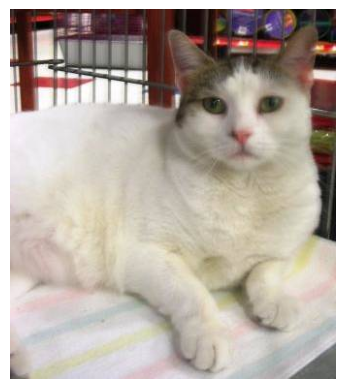

In [15]:
import cv2
import matplotlib.pyplot as plt
import os

img_path = "/content/drive/MyDrive/threec/cat and dogs image dataset/cats_set/cat.4292.jpg"

img = cv2.imread(img_path)
if img is None:
    print("Image not found. Check path.")
else:
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.imshow(img)
    plt.axis("off")
    plt.show()


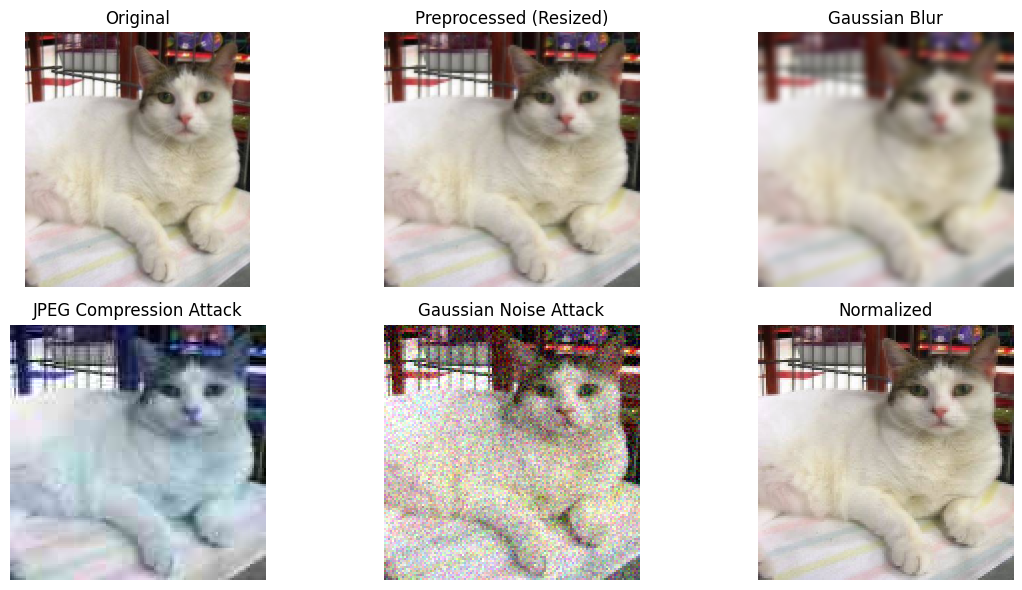

In [16]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img_path = "/content/drive/MyDrive/threec/cat and dogs image dataset/cats_set/cat.4292.jpg"

img = cv2.imread(img_path)
if img is None:
    raise ValueError("Image not found, check the path.")
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# preprocessing
resized = cv2.resize(img, (128, 128))
blurred = cv2.GaussianBlur(resized, (7, 7), 0)

# attack augmentations
noise = np.clip(resized + np.random.normal(0, 25, resized.shape), 0, 255).astype(np.uint8)
encode_param = [int(cv2.IMWRITE_JPEG_QUALITY), 30]
_, encimg = cv2.imencode('.jpg', resized, encode_param)
jpeg_attack = cv2.imdecode(encimg, 1)
jpeg_attack = cv2.cvtColor(jpeg_attack, cv2.COLOR_BGR2RGB)

# normalization
normalized = (resized / 255.0)

# show results
titles = [
    "Original",
    "Preprocessed (Resized)",
    "Gaussian Blur",
    "JPEG Compression Attack",
    "Gaussian Noise Attack",
    "Normalized"
]
images = [img, resized, blurred, jpeg_attack, noise, normalized]

plt.figure(figsize=(12, 6))
for i in range(6):
    plt.subplot(2, 3, i+1)
    plt.imshow(images[i])
    plt.title(titles[i])
    plt.axis("off")
plt.tight_layout()
plt.show()
